In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

In [2]:
df = pd.read_csv(
    "../data/raw/HAM10000/HAM10000_metadata.csv"
)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
df.info()
df.isnull().sum()

Shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']
<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
class_counts = df["dx"].value_counts()

print(class_counts)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


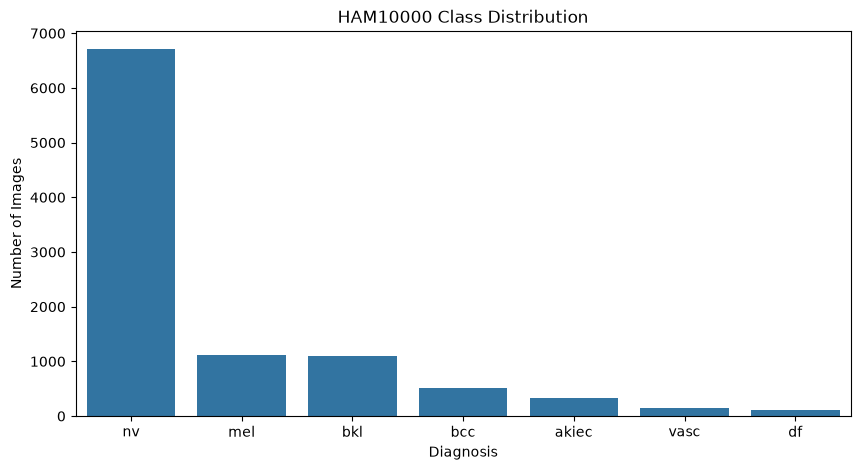

In [7]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("HAM10000 Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Images")

plt.show()

In [8]:
image_dir_1 = "../data/raw/HAM10000/HAM10000_images_part_1"
image_dir_2 = "../data/raw/HAM10000/HAM10000_images_part_2"

print(os.listdir(image_dir_1)[:5])
print(os.listdir(image_dir_2)[:5])

['ISIC_0024306.jpg', 'ISIC_0024307.jpg', 'ISIC_0024308.jpg', 'ISIC_0024309.jpg', 'ISIC_0024310.jpg']
['ISIC_0029306.jpg', 'ISIC_0029307.jpg', 'ISIC_0029308.jpg', 'ISIC_0029309.jpg', 'ISIC_0029310.jpg']


Image ID: ISIC_0027419
Image size: (600, 450)


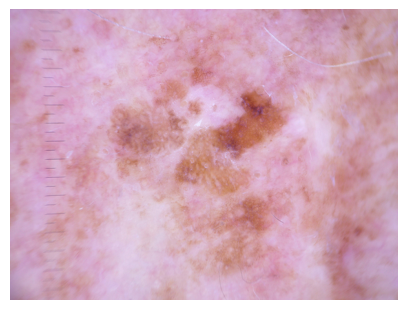

In [9]:
image_id = df.iloc[0]["image_id"]

image_path = os.path.join(
    image_dir_1,
    image_id + ".jpg"
)

img = Image.open(image_path)

print("Image ID:", image_id)
print("Image size:", img.size)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

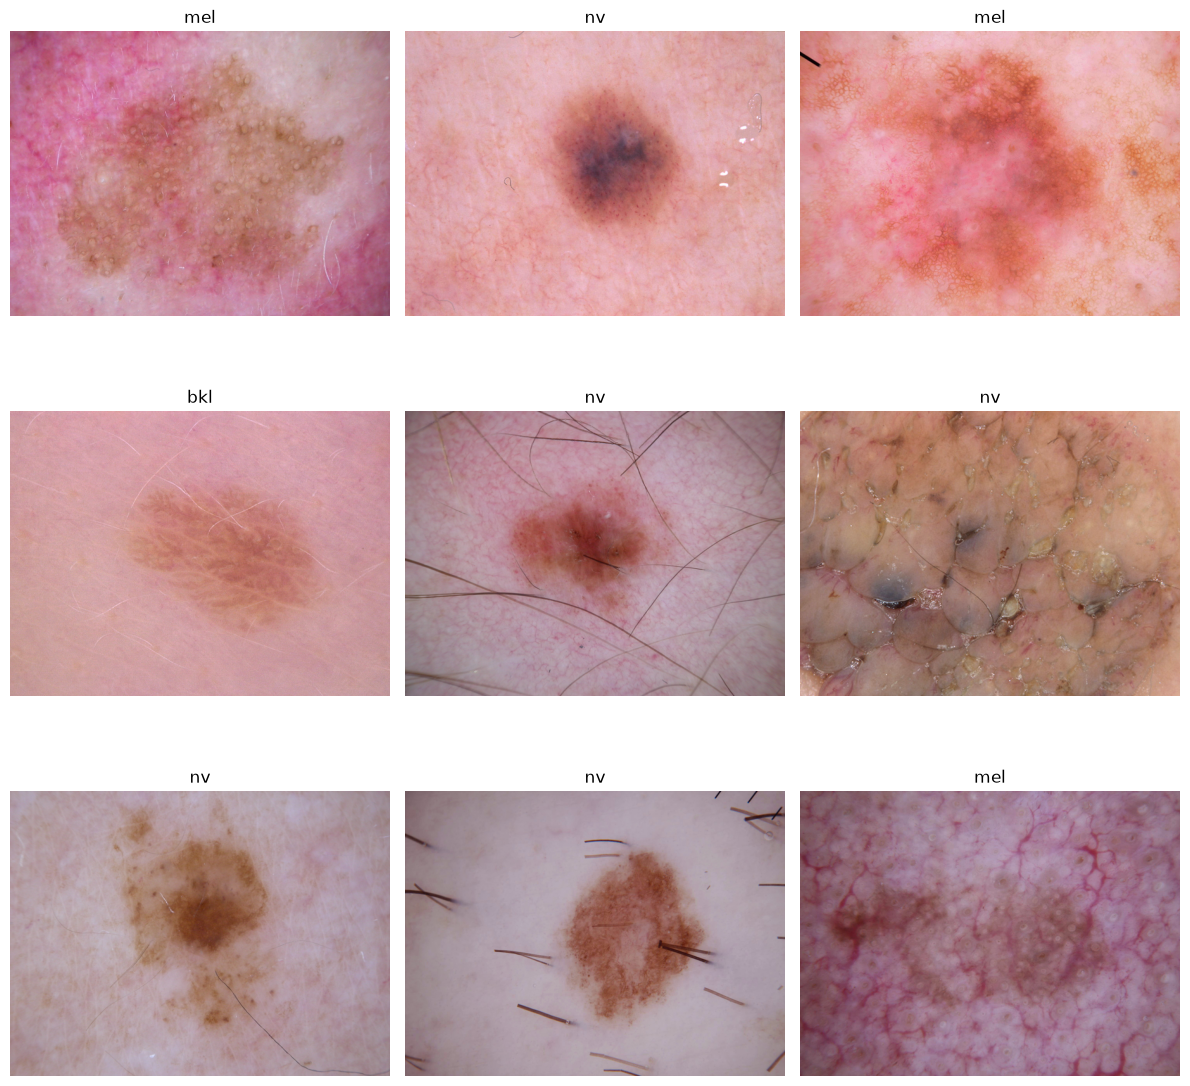

In [11]:
sample = df.sample(9, random_state=42)

plt.figure(figsize=(12, 12))

for i, (_, row) in enumerate(sample.iterrows()):

    image_id = row["image_id"]

    if os.path.exists(
        os.path.join(image_dir_1, image_id + ".jpg")
    ):
        path = os.path.join(
            image_dir_1,
            image_id + ".jpg"
        )
    else:
        path = os.path.join(
            image_dir_2,
            image_id + ".jpg"
        )

    img = Image.open(path)

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(row["dx"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [12]:
malignant_classes = ["mel", "bcc", "akiec"]

df["target"] = df["dx"].apply(
    lambda x: 1 if x in malignant_classes else 0
)

df[["dx", "target"]].head()

,dx,target
0,bkl,0
1,bkl,0
2,bkl,0
3,bkl,0
4,bkl,0


In [13]:
pd.crosstab(df["dx"], df["target"])

target,0,1
dx,,
akiec,0,327
bcc,0,514
bkl,1099,0
df,115,0
mel,0,1113
nv,6705,0
vasc,142,0


In [14]:
target_counts = df["target"].value_counts()

print(target_counts)

target
0    8061
1    1954
Name: count, dtype: int64


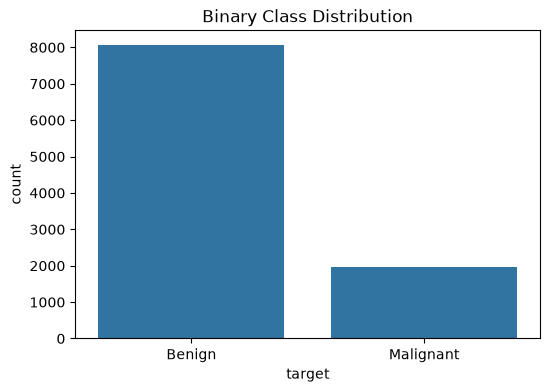

In [15]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="target"
)

plt.xticks(
    [0, 1],
    ["Benign", "Malignant"]
)

plt.title("Binary Class Distribution")

plt.show()

In [16]:
import os

image_dirs = [
    "../data/raw/HAM10000/HAM10000_images_part_1",
    "../data/raw/HAM10000/HAM10000_images_part_2"
]

def find_image(image_id):
    for directory in image_dirs:
        path = os.path.join(directory, image_id + ".jpg")
        if os.path.exists(path):
            return path
    return None

In [17]:
test_id = df.iloc[0]["image_id"]

print(test_id)
print(find_image(test_id))

ISIC_0027419
../data/raw/HAM10000/HAM10000_images_part_1\ISIC_0027419.jpg


In [18]:
df["image_path"] = df["image_id"].apply(find_image)

print("Total records:", len(df))
print("Images found:", df["image_path"].notna().sum())
print("Images missing:", df["image_path"].isna().sum())

Total records: 10015
Images found: 10015
Images missing: 0
